# Exercise 11: Machine Learning Pipeline - Classification Project

## Overview
This exercise demonstrates a complete machine learning workflow: from raw data loading and exploratory analysis through data preprocessing, feature engineering, model training, evaluation, and final model serialization. You'll work with a classification problem to predict economic outcomes based on multiple features.

## Learning Objectives
- **Data Exploration**: Load and analyze real-world datasets, identify missing values and data patterns
- **Data Preprocessing**: Handle missing values, encode categorical features, and scale numerical data appropriately
- **Feature Engineering**: Prepare features and targets for machine learning models
- **Model Training**: Train a Logistic Regression classifier using scikit-learn
- **Model Evaluation**: Assess model performance using multiple metrics (accuracy, precision, recall, F1-score, confusion matrix)
- **Model Persistence**: Save and load trained models using joblib for future predictions

## Dataset
- **Source**: EconomicsOfScale.csv
- **Target**: Classification problem (binary outcome)
- **Features**: Multiple numerical and categorical variables
- **Size**: Assess during exploratory analysis

## Q1: Data Loading and Exploratory Analysis

In this phase, we load the EconomicsOfScale dataset and perform initial exploratory analysis to understand:
- Dataset shape and size
- Feature names and data types
- Missing values and data quality issues
- Basic statistical summaries of numerical features

In [1]:
"""
Machine Learning Pipeline: Classification Project - Library Imports

Required Libraries:
- pandas: Data manipulation and analysis (loading CSV, data exploration)
- sklearn.model_selection.train_test_split: Split data into training and test sets
- sklearn.preprocessing.LabelEncoder: Encode categorical variables as numerical values
- sklearn.linear_model.LogisticRegression: Binary/multiclass classification model
- sklearn.metrics: Model performance evaluation (accuracy, precision, recall, F1-score)
- joblib: Serialize and deserialize trained models for later use
"""

import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [2]:
"""
Load Dataset from CSV file

This cell loads the EconomicsOfScale.csv dataset into a pandas DataFrame.
The dataset contains various economic features used for classification.

Returns:
    DataFrame: cost_df containing all features and target variable
"""

cost_df = pd.read_csv('dataset/EconomiesOfScale.csv')

In [3]:
print("[Data Head (First 5 Rows)]")
cost_df.head()

[Data Head (First 5 Rows)]


,Number of Units,Manufacturing Cost
0,1.000000,95.066056
1,1.185994,96.531750
2,1.191499,73.661311
3,1.204771,95.566843
4,1.298773,98.777013


### Step 1: Preview Data
Examine the first and last few rows to understand data structure and values.

In [4]:
print("[Data Tail (Last 5 Rows)]")
cost_df.tail()

[Data Tail (Last 5 Rows)]


,Number of Units,Manufacturing Cost
995,8.099710,23.855067
996,8.739752,27.536542
997,8.780888,25.973787
998,8.897700,25.138311
999,10.000000,21.547777


In [5]:
print("[Data Info (Structure and Types)]")
cost_df.info()

[Data Info (Structure and Types)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Number of Units     1000 non-null   float64
 1   Manufacturing Cost  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


### Step 2: Dataset Structure and Metadata
Inspect data types, column information, and verify dataset dimensions.

In [6]:
print("[Data Describe (Statistical Summary)]")
cost_df.describe()

[Data Describe (Statistical Summary)]


,Number of Units,Manufacturing Cost
count,1000.000000,1000.000000
mean,4.472799,40.052999
std,1.336241,10.595322
min,1.000000,20.000000
25%,3.594214,32.912036
50%,4.435958,38.345781
75%,5.324780,44.531822
max,10.000000,100.000000


In [7]:
SHAPE = cost_df.shape
print(f"Data Dimensions (Shape): {SHAPE}")

Data Dimensions (Shape): (1000, 2)


In [8]:
print("Missing (Null) Values per Column:")
print(cost_df.isnull().sum())
cost_df.isnull()

Missing (Null) Values per Column:
Number of Units       0
Manufacturing Cost    0
dtype: int64


,Number of Units,Manufacturing Cost
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
995,False,False
996,False,False
997,False,False
998,False,False


In [9]:
print("Total Duplicate Rows:")
print(cost_df.duplicated().sum())
cost_df.duplicated()

Total Duplicate Rows:
0


0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

## Q2: Data Visualization

In this phase, we create visual representations of the data to identify patterns and relationships:
- Scatter plots showing relationships between features
- Regression lines indicating linear trends
- Distribution analysis to understand feature characteristics

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### - Figure 1: Scatter plot  


Displaying Figure 1: Scatter Plot


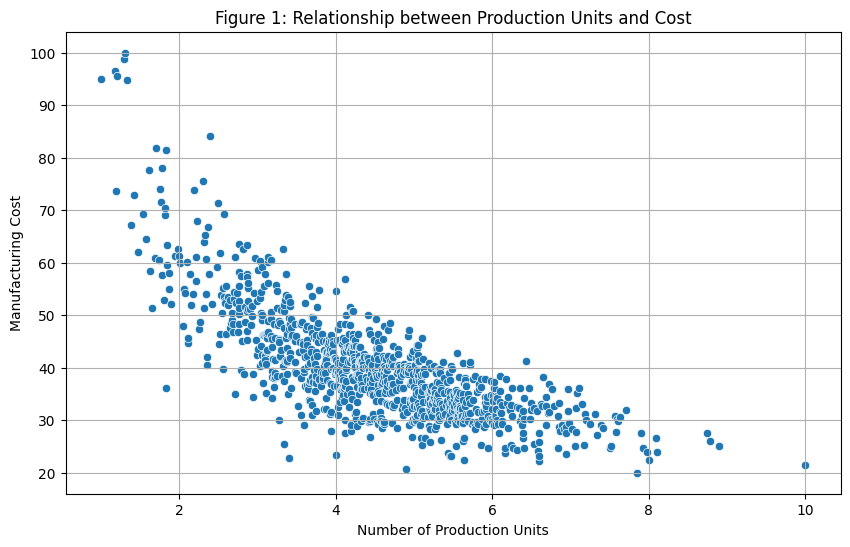

In [11]:
print("Displaying Figure 1: Scatter Plot")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cost_df, x='Number of Units', y='Manufacturing Cost')
#plt.scatter(cost_df["Number of Units"], cost_df["Manufacturing Cost"])
plt.title('Figure 1: Relationship between Production Units and Cost')
plt.xlabel('Number of Production Units')
plt.ylabel('Manufacturing Cost')
plt.grid(True)
plt.show()

### - Figure 2: Scatter plot with Linear Regression Line 

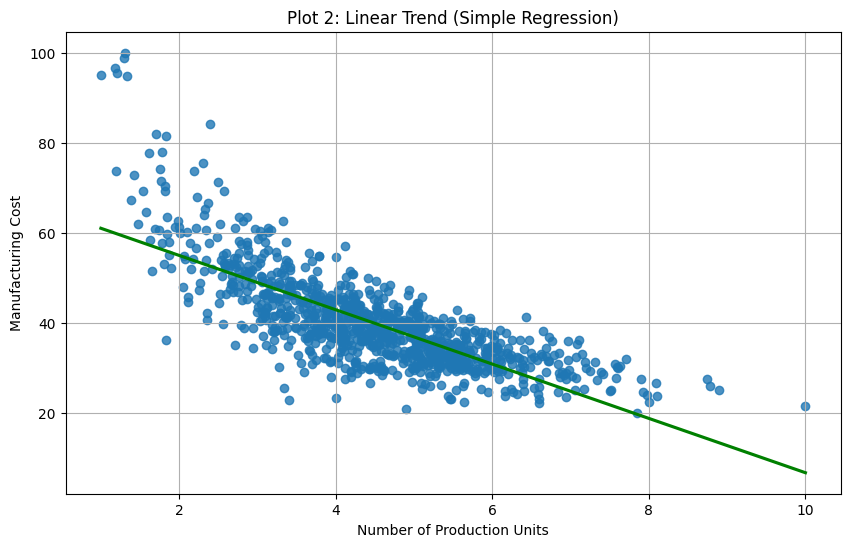

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(data=cost_df, x='Number of Units', y='Manufacturing Cost', ci=None, line_kws={"color": "green"})
plt.title('Plot 2: Linear Trend (Simple Regression)')
plt.xlabel('Number of Production Units')
plt.ylabel('Manufacturing Cost')
plt.grid(True)
plt.show()

### - Figure 3: Plot to examine data distribution  


### **Option 1:**

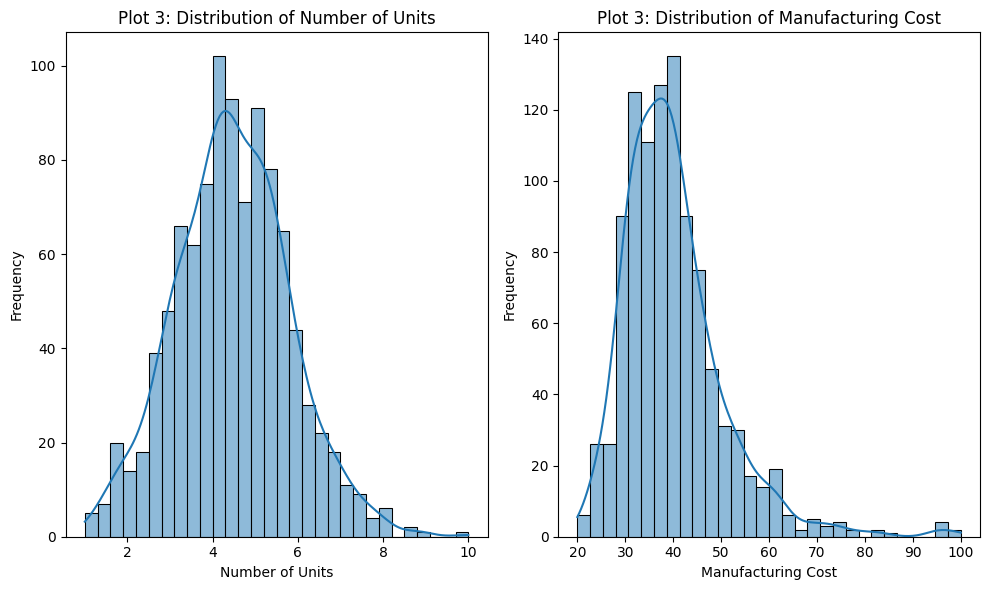

In [13]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.histplot(cost_df['Number of Units'], kde=True, bins=30)
plt.title('Plot 3: Distribution of Number of Units')
plt.xlabel('Number of Units')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sns.histplot(cost_df['Manufacturing Cost'], kde=True, bins=30)
plt.title('Plot 3: Distribution of Manufacturing Cost')
plt.xlabel('Manufacturing Cost')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### **Option2:**

Displaying Figure 3: Joint Plot (Different Angle)


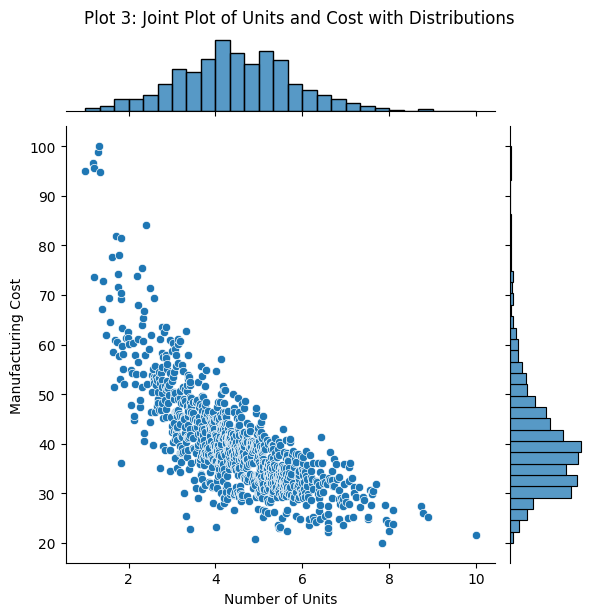

In [14]:
# A jointplot is excellent for this. It shows the scatter (relationship)
print("Displaying Figure 3: Joint Plot (Different Angle)")
sns.jointplot(data=cost_df, x='Number of Units', y='Manufacturing Cost')
plt.suptitle('Plot 3: Joint Plot of Units and Cost with Distributions', y=1.02)
plt.show()

### **Option3:**

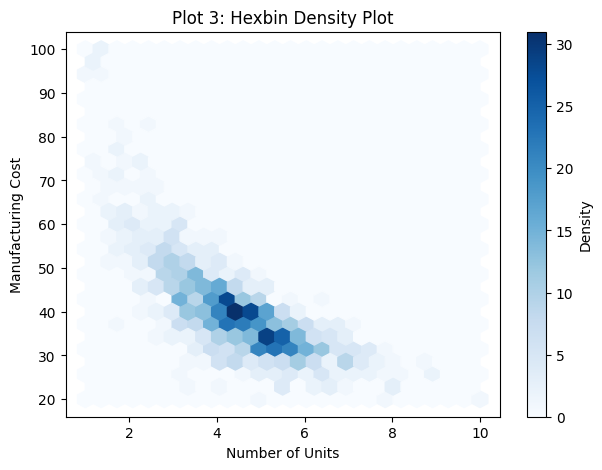

In [15]:
plt.figure(figsize=(7,5))
plt.hexbin(cost_df['Number of Units'], cost_df['Manufacturing Cost'], gridsize=25, cmap='Blues')
plt.title('Plot 3: Hexbin Density Plot')
plt.xlabel('Number of Units')
plt.ylabel('Manufacturing Cost')
plt.colorbar(label='Density')
plt.show()

### **Option4:**

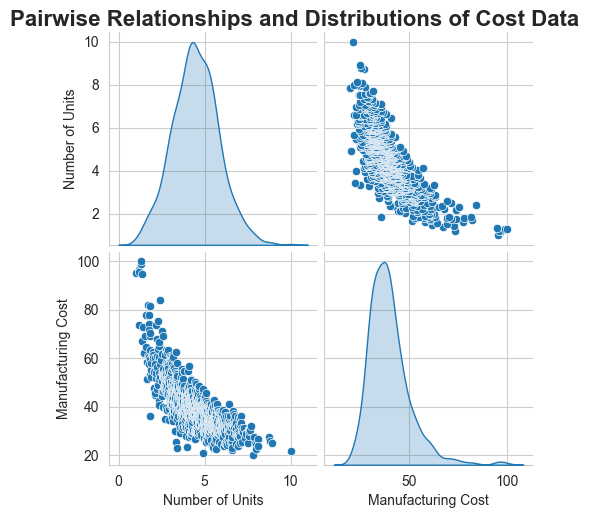

In [16]:
sns.set_style("whitegrid")
sns.pairplot(cost_df, diag_kind="kde")
plt.suptitle("Pairwise Relationships and Distributions of Cost Data", y=1.02, fontsize=16, fontweight='bold')
plt.show()

## Q3: Feature Engineering and Data Splitting

In this phase, we prepare the data for model training:
- Define features (X) - the input variables
- Define target (y) - the label to predict
- Split data into training (80%) and test (20%) sets
- Verify dimensions of train/test splits

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

###  1. Define Feature (X) and Label (Y)


In [18]:
"""
Step 1: Define Features (X) and Target Label (y)

This step separates the independent variables (X) from the dependent variable (y).
X contains the feature columns used for prediction.
y contains the target variable we want to predict.

Variables:
    x_col (str): Name of the feature column (independent variable)
    y_col (str): Name of the target column (dependent variable)
    X (DataFrame): Feature matrix with shape (n_samples, n_features)
    y (Series): Target vector with shape (n_samples,)
"""

x_col = 'Number of Units'
y_col = 'Manufacturing Cost'

X = cost_df[[x_col]] 
y = cost_df[y_col]

print(f"--- 1. Defined X (features) and y (label) ---")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

--- 1. Defined X (features) and y (label) ---
X shape: (1000, 1)
y shape: (1000,)


###  2. Split Data into Train/Test 


In [19]:
"""
Step 2: Split Data into Training and Test Sets

Divides the data into two sets:
- Training set (80%): Used to train the model
- Test set (20%): Used to evaluate model performance on unseen data

This prevents overfitting by ensuring the model is tested on data it hasn't seen.

Parameters:
    test_size=0.2: 20% of data reserved for testing
    random_state=42: Seed for reproducibility
"""

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Display Split Dimensions

In [20]:
print("--- 3. Dimensions of Train/Test Splits ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

print("\nData split successfully.") 

--- 3. Dimensions of Train/Test Splits ---
X_train shape: (800, 1)
y_train shape: (800,)
X_test shape : (200, 1)
y_test shape : (200,)

Data split successfully.


## Q4: Model Training - Linear Regression Baseline

In this phase, we train a Linear Regression model as a baseline:
- Instantiate the model
- Fit the model to training data
- Make predictions on test data
- Evaluate regression performance with appropriate metrics

In [21]:
from sklearn.linear_model import LinearRegression
import numpy as np

### 1. Linear Regression with Intercept (fit_intercept=True)

In [22]:
"""
Train Linear Regression Model WITH Intercept (Standard Model)

This creates a linear regression model with an intercept (bias) term.
The model fits the equation: y = mx + b
where m is the slope (coefficient) and b is the intercept.

Returns:
    lr1: Fitted LinearRegression model ready for predictions
"""

lr1 = LinearRegression(fit_intercept=True)
lr1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 2. Print coefficients and intercept (lr)

In [23]:
print("--- 1. Model WITH Intercept (lr1) ---")
print(f"Coefficient (Slope): {lr1.coef_}")
print(f"Intercept (Bias)  : {lr1.intercept_}")

--- 1. Model WITH Intercept (lr1) ---
Coefficient (Slope): [-6.21850698]
Intercept (Bias)  : 67.89012908512075


### 3. Linear Regression WITHOUT Intercept (fit_intercept=False)

In [24]:
lr2 = LinearRegression(fit_intercept=False)
lr2.fit(X_train, y_train)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 4. Print coefficients and intercept (lr2) and compare

In [25]:
print("--- 2. Model WITHOUT Intercept (lr2) ---")
print(f"Coefficient (Slope): {lr2.coef_}")
print(f"Intercept (Bias)  : {lr2.intercept_}")

--- 2. Model WITHOUT Intercept (lr2) ---
Coefficient (Slope): [7.750607]
Intercept (Bias)  : 0.0


- **  Interpretation and Comparison **

In [26]:
print("Model 'lr1' (with intercept):")
print(f"This model follows the equation: Cost = {lr1.coef_[0]:.2f} * (Units) + {lr1.intercept_:.2f}")
print("This is the standard model. The intercept represents the 'base cost' even if zero units are produced (e.g., fixed costs).")

print("\nModel 'lr2' (without intercept):")
print(f"This model follows the equation: Cost = {lr2.coef_[0]:.2f} * (Units) + 0")
print("This model was forced to pass through the origin (0,0).")

print("\nComparison:")
print("The coefficients are different because 'lr2' is constrained. Forcing the intercept to be zero often results in a poorer fit, as the line cannot adjust its 'height' and can only pivot from the origin. The standard model 'lr1' is almost always preferred unless you have a strong theoretical reason to believe the relationship must pass through (0,0).")

Model 'lr1' (with intercept):
This model follows the equation: Cost = -6.22 * (Units) + 67.89
This is the standard model. The intercept represents the 'base cost' even if zero units are produced (e.g., fixed costs).

Model 'lr2' (without intercept):
This model follows the equation: Cost = 7.75 * (Units) + 0
This model was forced to pass through the origin (0,0).

Comparison:
The coefficients are different because 'lr2' is constrained. Forcing the intercept to be zero often results in a poorer fit, as the line cannot adjust its 'height' and can only pivot from the origin. The standard model 'lr1' is almost always preferred unless you have a strong theoretical reason to believe the relationship must pass through (0,0).


## Q5: Polynomial Regression with Multiple Degrees

In this phase, we explore non-linear relationships by training polynomial regression models:
- Transform features to include polynomial terms (degrees 2, 3, 4, 5, 10)
- Train separate models for each polynomial degree
- Compare model complexity vs performance
- Identify potential overfitting as degree increases
- Visualize predictions for each model against test data

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd


In [28]:
"""
Define Polynomial Degrees to Test

This creates a list of polynomial degrees to explore.
Higher degrees allow the model to fit more complex patterns,
but risk overfitting with too much complexity.

Degrees to test: 2, 3, 4, 5, 10
"""

# Define the degrees we need to test
degrees = [2, 3, 4, 5, 10]

In [29]:
# Dictionary to store all transformers and models for later use
poly_models = {}
poly_transformers = {}

In [30]:
print("--- Training Polynomial Regression Models ---")

for degree in degrees:
    print(f"\nTraining Model with Degree = {degree}")
    
    # Define Polynomial Features Transformer
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    
    # Store the transformer
    poly_transformers[degree] = poly_features

    # Transform the Training Data
    X_train_poly = poly_features.fit_transform(X_train)

    # Define and Train the Linear Regression Model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Store the trained model
    poly_models[degree] = model

    # Print Results (Coefficients) for the trained model
    print(f"  Shape of transformed X_train_poly: {X_train_poly.shape}")
    print(f"  Intercept (Bias): {model.intercept_:.4f}")
    # Display the first few coefficients
    print(f"  Coefficients: {model.coef_}")
    print("----------------------------------------------------------------------")

print("\nAll polynomial models trained and saved in 'poly_models' dictionary.")

--- Training Polynomial Regression Models ---

Training Model with Degree = 2
  Shape of transformed X_train_poly: (800, 3)
  Intercept (Bias): 92.0358
  Coefficients: [  0.         -17.81636965   1.27181952]
----------------------------------------------------------------------

Training Model with Degree = 3
  Shape of transformed X_train_poly: (800, 4)
  Intercept (Bias): 114.0387
  Coefficients: [  0.         -34.51814321   5.05171512  -0.26070502]
----------------------------------------------------------------------

Training Model with Degree = 4
  Shape of transformed X_train_poly: (800, 5)
  Intercept (Bias): 133.2471
  Coefficients: [ 0.00000000e+00 -5.48053513e+01  1.21644641e+01 -1.26644861e+00
  4.90848244e-02]
----------------------------------------------------------------------

Training Model with Degree = 5
  Shape of transformed X_train_poly: (800, 6)
  Intercept (Bias): 162.8677
  Coefficients: [ 0.00000000e+00 -9.54138252e+01  3.19305847e+01 -5.63692225e+00
  4.945

# Q6  : Plotting and Prediction

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [32]:
def plot_polynomial(X, y, degree):
    
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    sort_index = np.argsort(X.iloc[:,0])
    X_sorted = X.iloc[sort_index, 0]
    y_sorted = np.array(y)[sort_index]
    y_pred_sorted = y_pred[sort_index]

    plt.figure(figsize=(7,5))
    
    # Plot Actual Data (Scatter Plot)
    plt.scatter(X, y, label="Real Data", color='gray', alpha=0.6)

    # Plot Predicted Curve
    plt.plot(X_sorted, y_pred_sorted, label=f"Degree {degree} Prediction", linewidth=3)
    plt.title(f"Polynomial Regression - Degree {degree}")
    plt.xlabel('Number of Units')
    plt.ylabel('Manufacturing Cost')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model




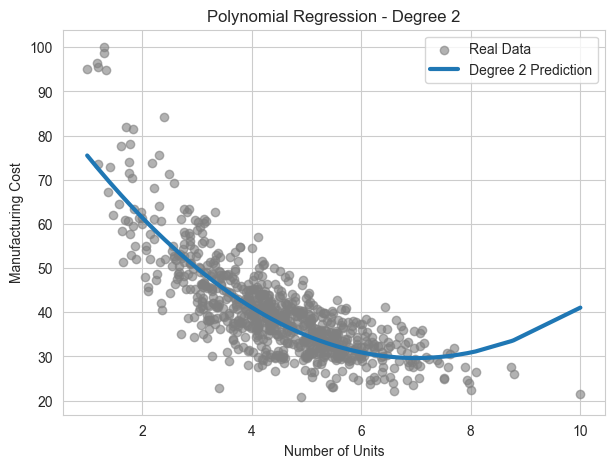

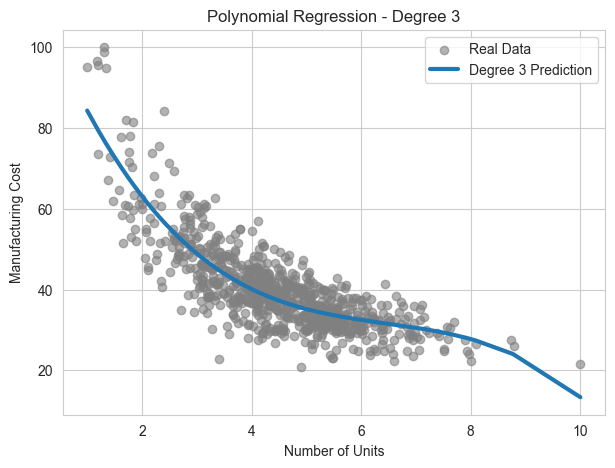

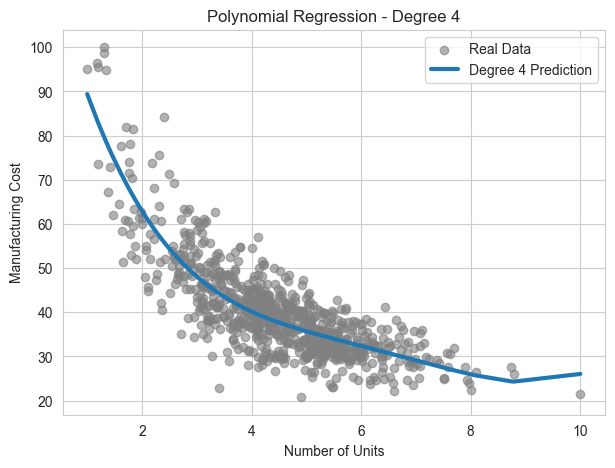

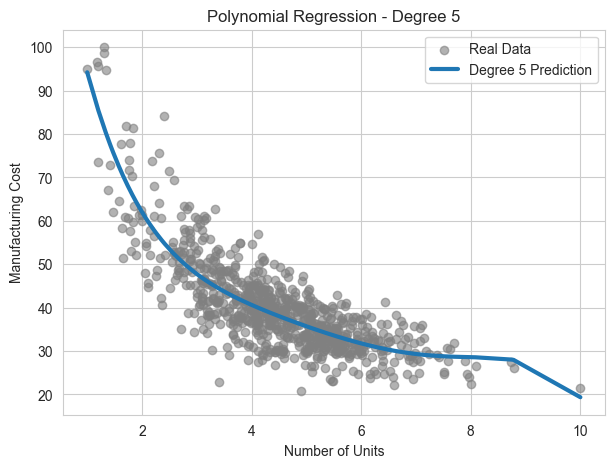

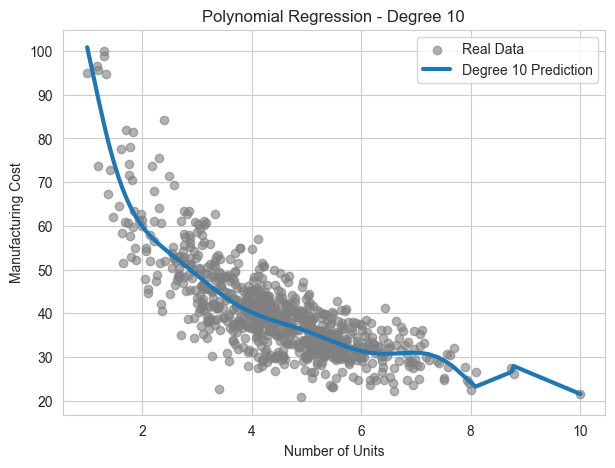

In [33]:
for degree in degrees:
    plot_polynomial(X_train, y_train, degree)

# Q7: Prediction on Test and Plotting the Curves

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

### 1. Linear Models - Predict on Test Data and Plot Curves

In [35]:
# Predictions using both linear models
y_pred_lin1 = lr1.predict(X_test)
y_pred_lin2 = lr2.predict(X_test)

# Sort the values for smooth plot curves
sorted_index = np.argsort(X_test.iloc[:,0])
X_sorted = X_test.iloc[sorted_index, 0]
y_test_sorted = np.array(y_test)[sorted_index]
y_pred_lin1_sorted = y_pred_lin1[sorted_index]
y_pred_lin2_sorted = y_pred_lin2[sorted_index]

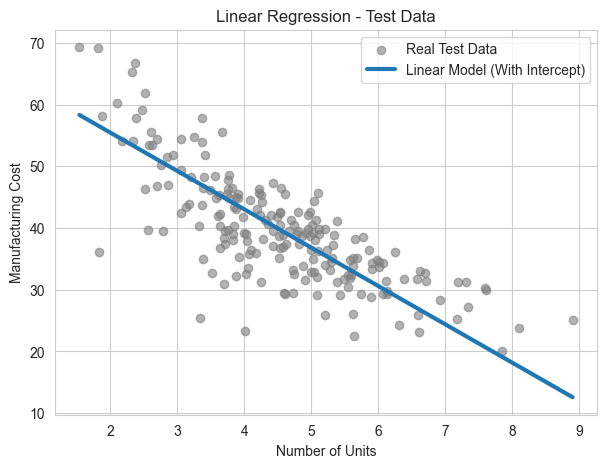

In [36]:
# ----- Plot Linear Model (with intercept) -----
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, label="Real Test Data", color='gray', alpha=0.6)
plt.plot(X_sorted, y_pred_lin1_sorted, label="Linear Model (With Intercept)", linewidth=3)
plt.title("Linear Regression - Test Data")
plt.xlabel('Number of Units')
plt.ylabel('Manufacturing Cost')
plt.legend()
plt.grid(True)
plt.show()

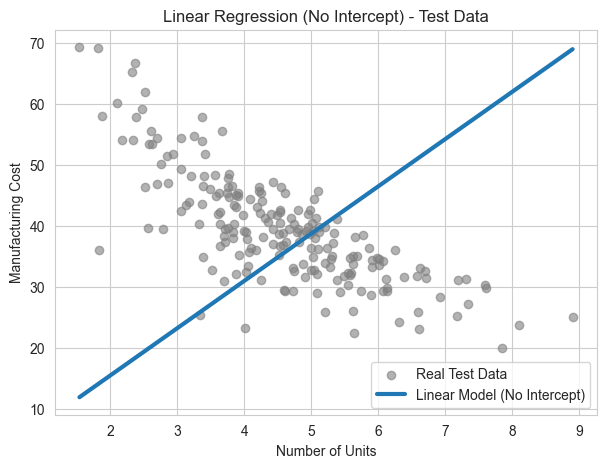

In [37]:
# ----- Plot Linear Model (without intercept) -----
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, label="Real Test Data", color='gray', alpha=0.6)
plt.plot(X_sorted, y_pred_lin2_sorted, label="Linear Model (No Intercept)", linewidth=3)
plt.title("Linear Regression (No Intercept) - Test Data")
plt.xlabel('Number of Units')
plt.ylabel('Manufacturing Cost')
plt.legend()
plt.grid(True)
plt.show()

### 2. Polynomial Regression Degree = 2 (Test Data)

In [38]:
poly2 = PolynomialFeatures(degree=2)
X_test_poly2 = poly2.fit_transform(X_test)
y_pred_poly2 = poly_models[2].predict(X_test_poly2)

y_pred_poly2_sorted = y_pred_poly2[sorted_index]

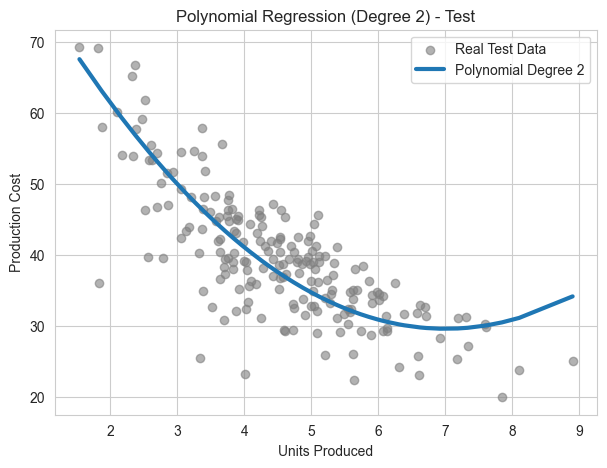

In [39]:
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, label="Real Test Data", color='gray', alpha=0.6)
plt.plot(X_sorted, y_pred_poly2_sorted, label="Polynomial Degree 2", linewidth=3)
plt.title("Polynomial Regression (Degree 2) - Test")
plt.xlabel("Units Produced")
plt.ylabel("Production Cost")
plt.legend()
plt.grid(True)
plt.show()

### 3. Polynomial Regression Degrees (3,4,5,10) - Test

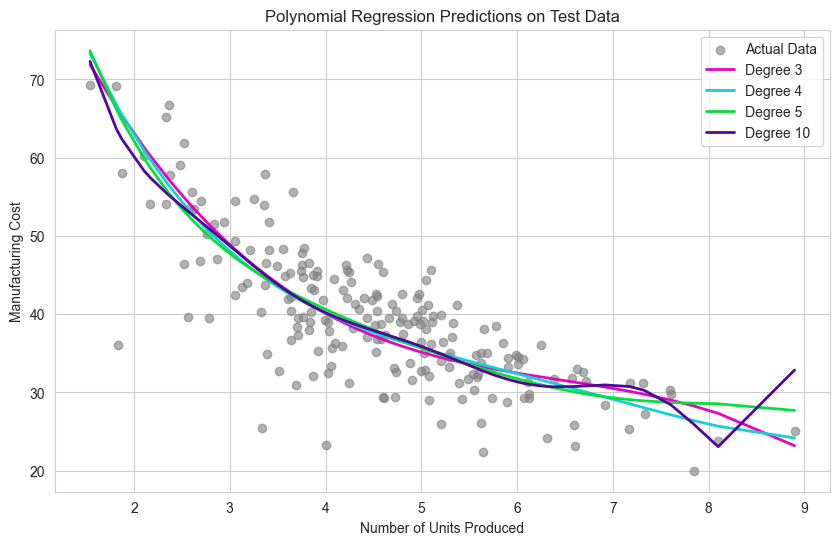

In [40]:
degrees = [3, 4, 5, 10]
colors = ["#e406bf",  
          "#16ced4fc",   
          "#07de39",   
          "#53069a"]   

plt.figure(figsize=(10,6))

plt.scatter(X_test, y_test, color='gray', alpha=0.6, label='Actual Data')

# Loop through polynomial degrees
for i, deg in enumerate(degrees):
    poly = PolynomialFeatures(degree=deg, include_bias=True)
    X_train_poly = poly.fit_transform(X_train)   
    X_test_poly = poly.transform(X_test)          

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    sorted_idx = np.argsort(X_test.values.ravel())
    plt.plot(X_test.values.ravel()[sorted_idx], y_pred[sorted_idx],
             color=colors[i], linewidth=2, label=f'Degree {deg}')

# Plot 
plt.xlabel("Number of Units Produced")
plt.ylabel("Manufacturing Cost")
plt.title("Polynomial Regression Predictions on Test Data")
plt.legend()
plt.grid(True)
plt.show()


# Q8: Model Evaluation

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from IPython.display import display 


- **METRICS AND EVALUATION FUNCTION DEFINITION**

In [42]:
def evaluate_model(y_true, y_pred):
    """
    Calculates evaluation metrics (MAE, MSE, RMSE, MAPE, R2) and returns them in a pandas DataFrame.

    Args:
        y_true (array-like): True values.
        y_pred (array-like): Predicted values.

    Returns:
        pd.DataFrame: A DataFrame containing the calculated metrics.
    """
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse) # RMSE is the square root of MSE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # DataFrame
    results = pd.DataFrame({
        "MAE": [mae],
        "MSE": [mse],
        "RMSE": [rmse],
        "MAPE (%)": [mape],
        "R2": [r2]
    })

    return results
 


In [43]:
# Initialization for the loop
degrees = [1, 2, 3, 4, 5, 10]
models = {}
results = pd.DataFrame(columns=["Degree", "Dataset", "MAE", "MSE", "RMSE", "MAPE (%)", "R2"])
 

for deg in degrees:
    
    # Feature Transformation
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Model Training
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    models[deg] = model

    # Prediction
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)

    #  Evaluate Train Set and Store Results 
    train_metrics_df = evaluate_model(y_train, y_pred_train)
    train_row = pd.DataFrame({
        "Degree": [deg],
        "Dataset": ["Train"],
        **train_metrics_df.iloc[0].to_dict() 
    })
    results = pd.concat([results, train_row], ignore_index=True)



    #  Evaluate Test Set and Store Results
    test_metrics_df = evaluate_model(y_test, y_pred_test)
    test_row = pd.DataFrame({
        "Degree": [deg],
        "Dataset": ["Test"],
        **test_metrics_df.iloc[0].to_dict() 
    })
    results = pd.concat([results, test_row], ignore_index=True)


pd.set_option('display.float_format', '{:.4f}'.format)
final_table = results.sort_values(by=['Degree', 'Dataset'], ascending=[True, False])

num_cols = ["MAE", "MSE", "RMSE", "MAPE (%)", "R2"]
final_table[num_cols] = final_table[num_cols].astype(float).round(4)
 

# Styled DataFrame 
styler = (final_table.style
          .set_caption("Final Model Evaluation (Train vs Test)")
          .background_gradient(subset=["MAE", "MSE", "RMSE", "MAPE (%)", "R2"], cmap="Blues")
         )

display(styler)

 

C:\Users\New\AppData\Local\Temp\ipykernel_8336\2818794804.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, train_row], ignore_index=True)


,Degree,Dataset,MAE,MSE,RMSE,MAPE (%),R2
0,1,Train,5.053400,50.299200,7.092200,0.129100,0.579700
1,1,Test,4.513900,35.197400,5.932700,0.123800,0.569600
2,2,Train,4.615900,38.753600,6.225200,0.116800,0.676200
3,2,Test,4.372300,33.226600,5.764200,0.119000,0.593700
4,3,Train,4.541800,35.832600,5.986000,0.114700,0.700600
5,3,Test,4.282600,32.287800,5.682200,0.115200,0.605200
6,4,Train,4.502100,35.171600,5.930600,0.113700,0.706100
7,4,Test,4.245100,31.561600,5.618000,0.113700,0.614000
8,5,Train,4.458300,34.769800,5.896600,0.112800,0.709500
9,5,Test,4.269100,31.503500,5.612800,0.114800,0.614800


- **plot all measures (MAE, MSE, RMSE, MAPE,R2) by Degree (Train vs Test)**

In [44]:
import matplotlib.ticker as mtick

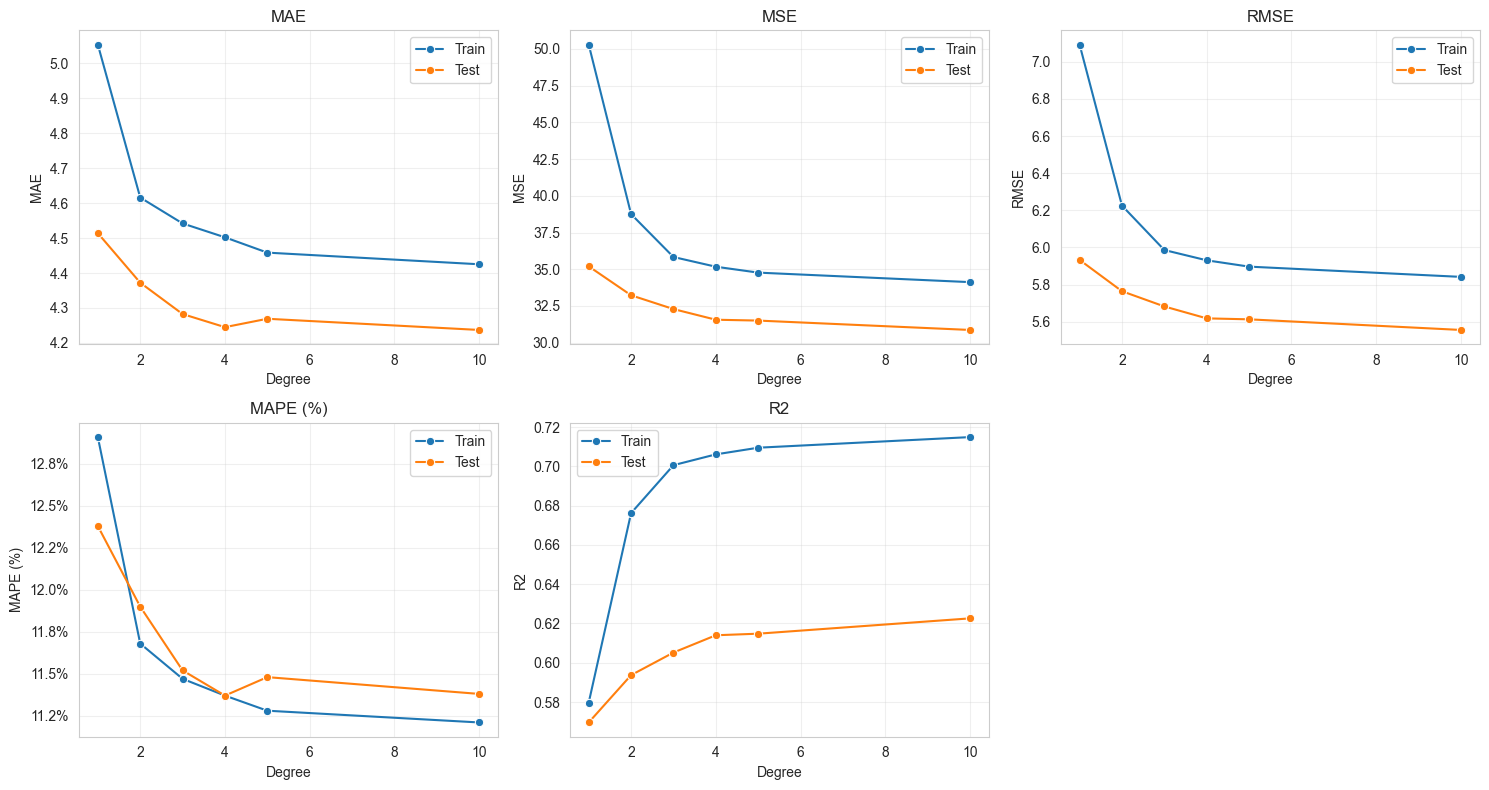

In [45]:
num_cols = ["MAE", "MSE", "RMSE", "MAPE (%)", "R2"]
final_table[num_cols] = final_table[num_cols].apply(pd.to_numeric).round(4)

test_rows = final_table[final_table["Dataset"] == "Test"]
 


metrics = ["MAE", "MSE", "RMSE", "MAPE (%)", "R2"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=final_table, x="Degree", y=metric, hue="Dataset", marker="o", ax=ax)
    ax.set_title(metric)
    ax.grid(alpha=0.3)
    if metric == "MAPE (%)":
        # show as percentage
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax.legend(loc="best")

# unused subplot -> turn off
axes[-1].axis("off")

plt.tight_layout()
plt.show()
 

# Regression Analysis of Production Cost

This project analyzed the relationship between **Units Produced** and **Production Cost** using **linear and polynomial regression models**. Models were evaluated on both **Train** and **Test** datasets using **MAE, MSE, RMSE, MAPE, and R²** metrics.

---

## 1. Linear vs Polynomial Models

* **Linear regression (Degree 1)** achieved moderate performance:

  * Train R² ≈ 0.58, Test R² ≈ 0.57
  * Error metrics (MAE, RMSE, MAPE) were higher than polynomial models.

* **Polynomial regression** improved accuracy consistently:

  * Test R² increased from 0.59 (Degree 2) to 0.62 (Degree 10)
  * RMSE decreased from ~5.93 (Linear) to ~5.56 (Degree 10)
  * MAE decreased slightly with increasing polynomial degree.

---

## 2. Effect of Polynomial Degree

* Increasing the polynomial degree (2 → 10) gradually improved Train and Test metrics.
* Minimal overfitting observed:

  * Train vs Test R² gap is small (0.714 → 0.623 for Degree 10)
  * MAE, RMSE, and MAPE remain stable across Train/Test datasets.

---

## 3. Error Metrics Summary (Test Data)

| Metric | Linear | Degree 2 | Degree 3 | Degree 4 | Degree 5 | Degree 10 |
| ------ | ------ | -------- | -------- | -------- | -------- | --------- |
| R²     | 0.570  | 0.594    | 0.605    | 0.614    | 0.615    | 0.623     |
| MAE    | 4.514  | 4.372    | 4.283    | 4.245    | 4.269    | 4.237     |
| RMSE   | 5.933  | 5.764    | 5.682    | 5.618    | 5.613    | 5.556     |
| MAPE % | 12.38% | 11.90%   | 11.52%   | 11.37%   | 11.48%   | 11.38%    |

---

## 4. Recommendations

* **Polynomial Regression (Degree 4–10)** is recommended for modeling production cost:

  * Captures nonlinear trends efficiently.
  * Provides a balance between accuracy and complexity.

* **Linear Regression** may be used for quick estimation but is less precise.

---

## 5. Conclusion

* The relationship between units produced and production cost is **nonlinear**.
* Polynomial regression models provide a **better fit** and **lower prediction error** than linear regression.
* Degrees 4–5 offer a good trade-off between model simplicity and accuracy.


## Q6: Model Serialization and Persistence

In this final phase, we save trained models to disk for future use:
- Save models using joblib for efficient serialization
- Enable loading pre-trained models without retraining
- Prepare models for deployment in production environments
- Document model versions and performance metrics

**Key Learning Points:**
- Why model persistence matters (save computation time, reproducibility)
- How to save and load sklearn models
- Best practices for model versioning and organization